In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [23]:
df = pd.read_csv(r"C:\Users\pc\Desktop\proyecto_Marcos\data\raw\Football_Dataset_2015_2025.csv")

In [24]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Date"] = df["Date"].dt.date

In [25]:
del df["Competition"]

In [26]:
def get_winner(row):
    if row["Home Goals"] > row["Away Goals"]:
        return "Home Team"
    elif row["Home Goals"] < row["Away Goals"]:
        return "Away Team"
    else:
        return "Draw"

df["Winner"] = df.apply(get_winner, axis=1)

In [39]:
# Normalizar nombres de equipos
unificar = {
    "Man City": "Manchester City",
    "PSG": "Paris Saint-Germain",
}

df["Home Team"] = df["Home Team"].replace(unificar)
df["Away Team"] = df["Away Team"].replace(unificar)

#CREACIÓN DE VARIABLES
# Partidos jugados
home_matches = df["Home Team"].value_counts()
away_matches = df["Away Team"].value_counts()

# Puntos usando Winner
df["Home_Points"] = df["Winner"].apply(lambda x: 3 if x == "Home Team" else 1 if x == "Draw" else 0)
df["Away_Points"] = df["Winner"].apply(lambda x: 3 if x == "Away Team" else 1 if x == "Draw" else 0)

# Tabla final
teams = sorted(set(df["Home Team"]).union(set(df["Away Team"])))
team_stats = pd.DataFrame(index=teams)
team_stats.index.name = "Team"

team_stats["Matches_Played"] = (
    home_matches.reindex(team_stats.index, fill_value=0) +
    away_matches.reindex(team_stats.index, fill_value=0)
)

team_stats["Total_Points"] = (
    df.groupby("Home Team")["Home_Points"].sum().reindex(team_stats.index, fill_value=0) +
    df.groupby("Away Team")["Away_Points"].sum().reindex(team_stats.index, fill_value=0)
)

team_stats["Total_Shots"] = (
    df.groupby("Home Team")["Shots (Home)"].sum().reindex(team_stats.index, fill_value=0) +
    df.groupby("Away Team")["Shots (Away)"].sum().reindex(team_stats.index, fill_value=0)
)

team_stats["Total_Goals"] = (
    df.groupby("Home Team")["Home Goals"].sum().reindex(team_stats.index, fill_value=0) +
    df.groupby("Away Team")["Away Goals"].sum().reindex(team_stats.index, fill_value=0)
)

team_stats["Average_Points"] = team_stats["Total_Points"] / team_stats["Matches_Played"]

team_stats = team_stats.sort_values(["Average_Points","Total_Points", "Matches_Played", "Total_Goals", "Total_Shots"], ascending=False).reset_index()

print(team_stats.head(20))

                   Team  Matches_Played  Total_Points  Total_Shots  \
0              Juventus             574           878         8841   
1       Manchester City             650           955         9759   
2               Chelsea             607           882         9176   
3               Arsenal             607           867         8850   
4         Bayern Munich             593           840         9054   
5             Liverpool             568           795         8804   
6   Paris Saint-Germain             606           837         9135   
7     Borussia Dortmund             292           402         4341   
8              AC Milan             591           813         8966   
9           Real Madrid             294           403         4355   
10            Barcelona             618           828         9354   

    Total_Goals  Average_Points  
0          1531        1.529617  
1          1645        1.469231  
2          1585        1.453048  
3          1547        

In [40]:
display(team_stats.head(20))

,Team,Matches_Played,Total_Points,Total_Shots,Total_Goals,Average_Points
0,Juventus,574,878,8841,1531,1.529617
1,Manchester City,650,955,9759,1645,1.469231
2,Chelsea,607,882,9176,1585,1.453048
3,Arsenal,607,867,8850,1547,1.428336
4,Bayern Munich,593,840,9054,1470,1.416526
5,Liverpool,568,795,8804,1375,1.399648
6,Paris Saint-Germain,606,837,9135,1416,1.381188
7,Borussia Dortmund,292,402,4341,722,1.376712
8,AC Milan,591,813,8966,1405,1.375635
9,Real Madrid,294,403,4355,706,1.370748


In [28]:
df

,Date,Home Team,Away Team,Home Goals,Away Goals,Possession % (Home),Possession % (Away),Shots (Home),Shots (Away),Corners (Home),Corners (Away),Fouls (Home),Fouls (Away),Winner,Year,Home_Points,Away_Points
0,2015-12-12,Barcelona,AC Milan,3,1,44,52,15,20,7,2,12,15,Home Team,2015,3,0
1,2022-07-20,Barcelona,Bayern Munich,0,5,52,42,23,19,4,10,13,7,Away Team,2022,0,3
2,2021-03-08,Manchester City,Bayern Munich,2,5,55,58,18,16,5,9,7,10,Away Team,2021,0,3
3,2022-12-08,Bayern Munich,Manchester City,5,1,63,40,8,12,2,3,15,8,Home Team,2022,3,0
4,2016-08-24,Barcelona,Juventus,0,1,41,57,9,12,4,7,11,9,Away Team,2016,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2021-03-08,Juventus,Paris Saint-Germain,2,2,67,55,10,16,7,6,9,12,Draw,2021,1,1
2996,2025-10-29,Juventus,Juventus,0,5,70,56,16,25,3,9,8,6,Away Team,2025,0,3
2997,2019-10-22,Bayern Munich,Paris Saint-Germain,5,2,61,43,22,6,9,3,15,5,Home Team,2019,3,0
2998,2022-06-05,Chelsea,Liverpool,3,2,42,37,7,13,5,7,10,6,Home Team,2022,3,0


Text(0.5, 1.0, 'Matriz de Correlación')

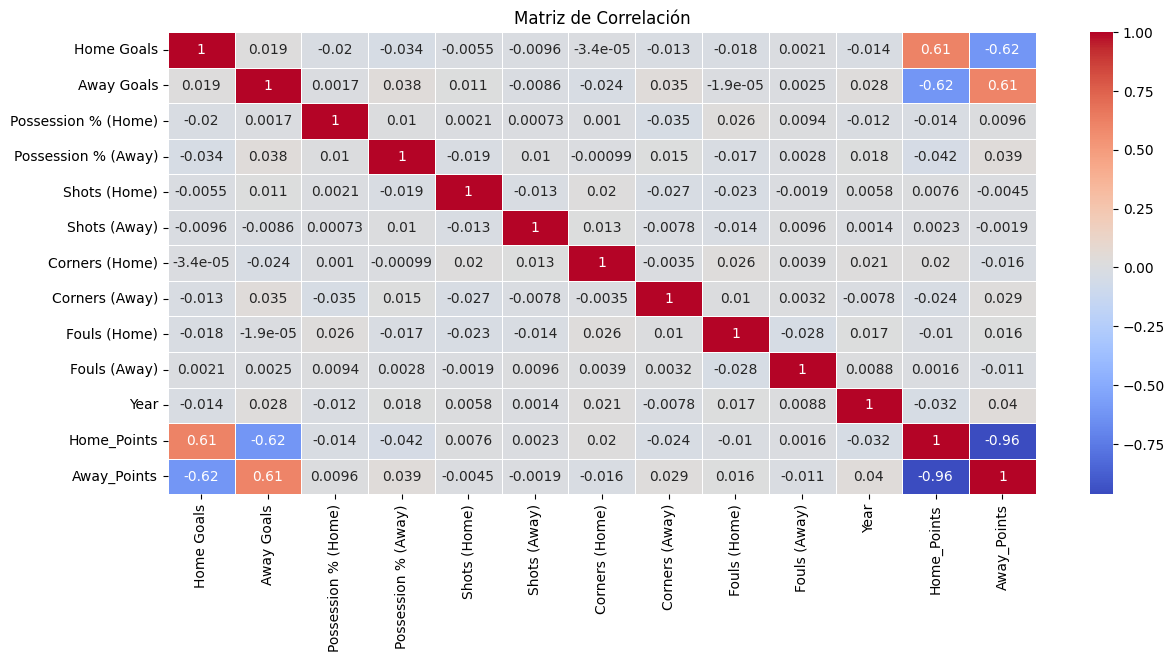

In [33]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')


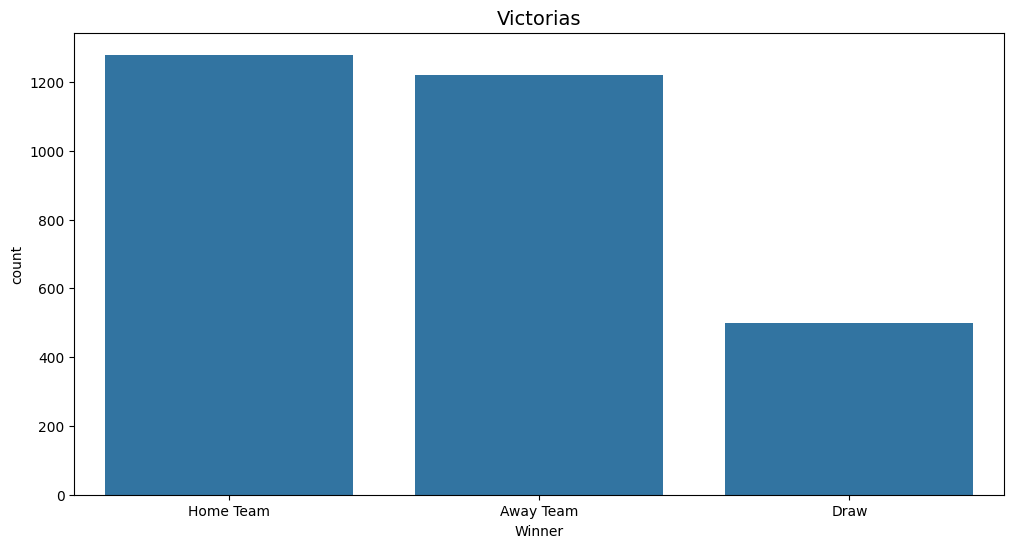

In [31]:
plt.figure(figsize=(12, 6))
sns.countplot(x="Winner", data=df, order=df["Winner"].value_counts().index)
plt.title("Victorias", fontsize=14)
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_1612\1842628754.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Team", y="Average_Points", data=team_stats, palette='Set1')


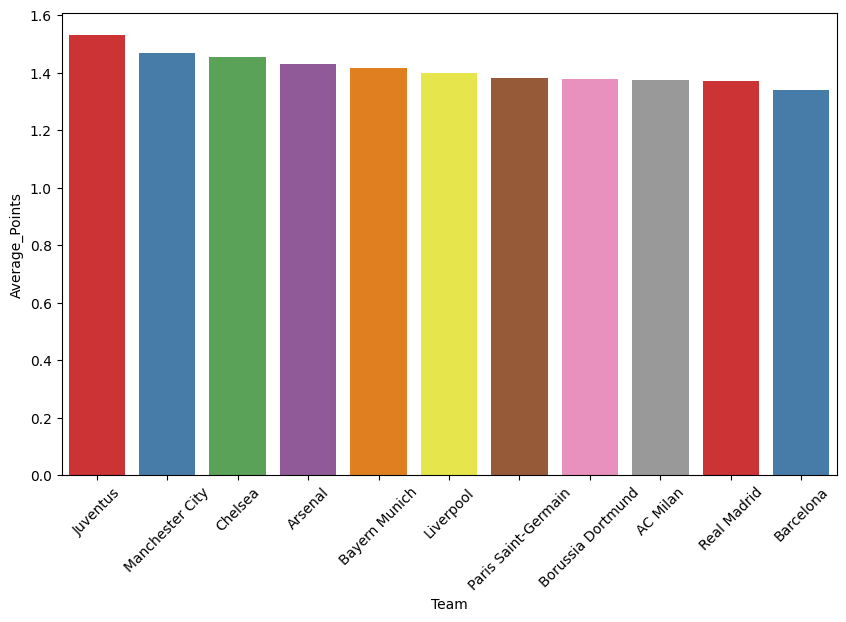

In [47]:
plt.figure(figsize=(10,6))
sns.barplot(x="Team", y="Average_Points", data=team_stats, palette='Set1')
plt.xticks(rotation=45)
plt.show()